<a href="https://colab.research.google.com/github/erdem-durmaz/AI-Projects/blob/main/Single%20Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
requirements_path = "/content/drive/MyDrive/requirements.txt"
#!pip install -r {requirements_path}

In [ ]:
import os
from typing import TypedDict, List, Literal
from urllib.parse import quote

import httpx
from google.colab import userdata

from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage, AIMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_groq import ChatGroq
import sqlite3
import uuid
from datetime import datetime


# -------- DB SETUP --------

conn = sqlite3.connect("/content/drive/MyDrive/chat_memory.db", check_same_thread=False)
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS messages (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    session_id TEXT NOT NULL,
    role TEXT NOT NULL,
    content TEXT NOT NULL,
    message_type TEXT,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")
conn.commit()


def save_message(session_id, role, content, message_type=None):
    cursor.execute("""
        INSERT INTO messages (session_id, role, content, message_type)
        VALUES (?, ?, ?, ?)
    """, (session_id, role, content, message_type))
    conn.commit()


def load_messages(session_id, limit=12):
    cursor.execute("""
        SELECT role, content
        FROM messages
        WHERE session_id = ?
        ORDER BY id DESC
        LIMIT ?
    """, (session_id, limit))

    rows = cursor.fetchall()
    rows.reverse()

    history = []
    for role, content in rows:
        if role == "user":
            history.append(HumanMessage(content=content))
        elif role == "assistant":
            history.append(AIMessage(content=content))
    return history



# -------- API KEY --------
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

# -------- HELPERS --------
def print_stream(stream):
    for step in stream:
        if "messages" in step and step["messages"]:
            step["messages"][-1].pretty_print()

# -------- TOOLS --------
search_tool = DuckDuckGoSearchRun()

@tool
def get_weather(city: str) -> str:
    """Get current weather for a city, use °C metric."""
    try:
        city_encoded = quote(city)
        resp = httpx.get(f"https://wttr.in/{city_encoded}?format=3", timeout=5)
        resp.raise_for_status()
        return resp.text
    except Exception:
        return "Güncel hava durumu verisi şu an alınamadı, wttr.in adresini kontrol edebilirsin."

@tool
def get_exchange_rate(currency: str = "USD") -> str:
    """Get current exchange rate against Turkish Lira (TRY).
    currency: USD, EUR, GBP gibi."""
    try:
        currency = currency.upper().strip()
        resp = httpx.get(f"https://open.er-api.com/v6/latest/{currency}", timeout=5)
        resp.raise_for_status()
        data = resp.json()

        if data.get("result") == "success" and "TRY" in data.get("rates", {}):
            rate = data["rates"]["TRY"]
            updated = data.get("time_last_update_utc", "bilinmiyor")
            return f"1 {currency} = {rate:.4f} TRY (güncelleme: {updated})"

        return "Kur bilgisi şu an alınamadı, güvenilir bir finans sitesini kontrol edebilirsin."
    except Exception:
        return "Kur bilgisi şu an alınamadı, güvenilir bir finans sitesini kontrol edebilirsin."

@tool
def web_search(query: str) -> str:
    """Search the web for current events, recent news, or live data."""
    try:
        return search_tool.run(query)
    except Exception:
        return "Güncel web arama sonucu şu an alınamadı, ilgili haber sitesini veya arama motorunu kontrol edebilirsin."

tools = [get_exchange_rate, get_weather, web_search]
tool_node = ToolNode(tools)

# -------- MODELS --------
tool_model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3
).bind_tools(tools)

base_model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.3
)

# -------- SYSTEM PROMPT --------
SYSTEM_PROMPT = SystemMessage(content="""

You are a helpful assistant.

CEVAP KURALLARI:
- Kısa ve net cevap ver.
- Gereksiz giriş yapma.
- Kullanıcı soru sormadıysa ekstra açıklama yapma.
- Güncel veri, canlı bilgi, bugün, şimdi, son durum, anlık kur, hava durumu,
  haber gibi sorularda tahmin yürütme.
- Uygun tool varsa mutlaka tool kullan.
- Eğer emin değilsen açıkça kısa şekilde belirt.
- Cevaplar doğal, akıcı ve sade olsun.
- Kullanıcının diliyle cevap ver.
- Eğer kullanıcı isteği tool için gerekli parametreyi içermiyorsa,
  tahmin yürütme.
- Tek kısa netleştirme sorusu sor.
- Kullanıcı kısa soruyorsa kısa cevap ver.
- Kullanıcı detay isterse detaylı cevap ver.
- Varsayılan cevap kısa olsun.

KRİTİK KURAL:
- Hava durumu, döviz, haber gibi tool gerektiren sorularda
  eğer gerekli parametre eksikse:
    - Asla tahmin yapma
    - Asla kendi cevabını üretme
    - Tool çağırma
    - Kullanıcıya kısa bir netleştirme sorusu sor

Örnek:
"Hava nasıl?" → "Hangi şehir için bakmamı istersin?"
"Dolar kaç?" → "Hangi para birimini sormak istiyorsun?"

FORMAT:
- Basit sorularda 1-3 cümle
- Açıklama istenirse maddeli anlat
- Sayısal veri varsa net formatta ver

""")

ANSWER_PROMPT = SystemMessage(content="""
You are a helpful assistant.

FINAL CEVAP KURALLARI:
- Aşağıdaki konuşma ve varsa tool sonucuna göre final kullanıcı cevabı üret.
- Tool çağırmaya çalışma.
- Sadece son kullanıcıya verilecek cevabı yaz.
- Kısa, net, doğal ol.
- Tool sonucu eksikse bunu kısa şekilde belirt.
- İç işleyişten bahsetme.
- Kullanıcının diliyle cevap ver.
- Gereksiz açılış cümlesi kullanma.
- Gereksiz kapanış cümlesi kullanma.
- Sonucu direkt ver.
- Tool sonucu ham metinse, kullanıcı dostu kısa cümleye çevir.
- Ama veri ekleme, uydurma yapma.
- Tool sonucunu yorumlarken yeni bilgi ekleme.
- Tool sonucunda olmayan zaman bilgisi (yarın, bugün vs.) ekleme.
- Eğer tool sonucu "current" ise onu aynen kullan.
- En son kullanıcı mesajı her zaman önceki konuşmalardan daha önceliklidir.
- Önceki mesajlardan gelen parametreleri taşımadan önce son mesajı analiz et.
- Eğer kullanıcı "yarın" gibi geleceğe yönelik sorarsa:
    - Tool desteklemiyorsa:
        - "Şu anki hava durumu..." diye cevap ver
        - VEYA kısa şekilde forecast olmadığını söyle

""")


# -------- STATE --------
class AgentState(TypedDict):
    messages: List[BaseMessage]
    tool_call_count: int

# -------- NODES --------
def agent_node(state: AgentState) -> AgentState:
    """İlk karar noktası: tool gerekir mi gerekmez mi?"""
    response = tool_model.invoke([SYSTEM_PROMPT] + state["messages"])
    print(f"TOOL CALLS: {getattr(response, 'tool_calls', None)}")
    return {
        "messages": state["messages"] + [response],
        "tool_call_count": state.get("tool_call_count", 0)
    }

def answer_node(state: AgentState) -> AgentState:
    """Tool sonucu geldiyse artık sadece final cevap yaz."""
    response = base_model.invoke([ANSWER_PROMPT] + state["messages"])
    return {
        "messages": state["messages"] + [response],
        "tool_call_count": state.get("tool_call_count", 0)
    }

def tool_node_with_counter(state: AgentState) -> AgentState:
    """Tool çalıştır ve sonucu state'e ekle."""
    result = tool_node.invoke(state)
    new_messages = result.get("messages", [])
    return {
        "messages": state["messages"] + new_messages,
        "tool_call_count": state.get("tool_call_count", 0) + 1
    }

# -------- EDGES --------
def should_use_tools(state: AgentState) -> Literal["tools", "__end__"]:
    last = state["messages"][-1]
    if getattr(last, "tool_calls", None):
        return "tools"
    return "__end__"

# -------- GRAPH --------
graph = StateGraph(AgentState)

graph.add_node("agent", agent_node)
graph.add_node("tools", tool_node_with_counter)
graph.add_node("answer", answer_node)

graph.add_edge(START, "agent")

graph.add_conditional_edges(
    "agent",
    should_use_tools,
    {
        "tools": "tools",
        "__end__": END
    }
)

graph.add_edge("tools", "answer")
graph.add_edge("answer", END)

agent = graph.compile()



# -------- HISTORY --------
session_id = f"chat_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:6]}"
print(session_id)

chat_history = load_messages(session_id)
MAX_HISTORY = 12



# -------- CLI LOOP --------
while True:
    print(f"History:{chat_history}")

    user_input = input("Enter: ").strip()
    if user_input.lower() in ["exit", "quit"]:
        break
    if not user_input:
        continue
    user_msg = HumanMessage(content=user_input)
    chat_history.append(user_msg)
    save_message(session_id="123", role="user", content=user_input)

    final_state = None


    for step in agent.stream(
        {
            "messages": chat_history,
            "tool_call_count": 0
        },
        stream_mode="values"
    ):
        final_state = step

    if final_state and "messages" in final_state:
        assistant_msg = final_state["messages"][-1]
        assistant_msg.pretty_print()

        chat_history.append(assistant_msg)
        save_message(session_id="123", role="assistant", content=assistant_msg.content)
        # Hafızayı kısalt
        chat_history = chat_history[-MAX_HISTORY:]



chat_20260602_101319_c5ea3c
History:[]
Enter: yarın hava nasıl?
TOOL CALLS: []
================================== Ai Message ==================================

Hangi şehir için bakmamı istersin?
History:[HumanMessage(content='yarın hava nasıl?', additional_kwargs={}, response_metadata={}), AIMessage(content='Hangi şehir için bakmamı istersin?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 709, 'total_tokens': 721, 'completion_time': 0.028854129, 'completion_tokens_details': None, 'prompt_time': 0.183640008, 'prompt_tokens_details': None, 'queue_time': 0.131782166, 'total_time': 0.212494137}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e87d2-e096-7663-8761-274a1f438af3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 709, 'output_tokens': 12, 'total_tokens': 72

KeyboardInterrupt: Interrupted by user

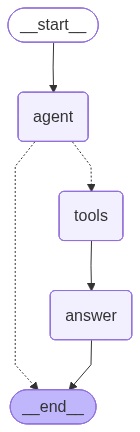

In [ ]:
# -------- GRAPH VIEW --------
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))